# 08 - LR vs RF Comparison

Side-by-side comparison of baseline LR (all genes) vs RF (variance-filtered).

In [1]:
import pandas as pd
from gtex_biomarkers.config import Config
from gtex_biomarkers.utils import build_comparison_table
from gtex_biomarkers.evaluation import plot_comparison_scatter, plot_comparison_barplot

Config.ensure_dirs()

lr_summary = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_pathology.csv")
rf_summary = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv")

## Comparison Table

In [2]:
comp = build_comparison_table(lr_summary, rf_summary)
print(f"RF better: {(comp['auc_diff'] > 0).sum()}")
print(f"LR better: {(comp['auc_diff'] < 0).sum()}")
print(f"Mean improvement: {comp['auc_diff'].mean():.4f}")
comp.to_csv(Config.TABLES_DIR / "comparison_lr_vs_rf.csv", index=False)
display(comp[["tissue", "category", "mean_auc_lr", "mean_auc_rf", "auc_diff"]])

RF better: 43
LR better: 16
Mean improvement: 0.0244


,tissue,category,mean_auc_lr,mean_auc_rf,auc_diff
16,Artery - Tibial,monckeberg,0.535535,0.661283,0.125748
42,Lung,macrophages,0.440230,0.564851,0.124622
52,Small Intestine - Terminal Ileum,nodularity,0.584680,0.703965,0.119285
6,Artery - Aorta,sclerotic,0.500076,0.615223,0.115148
57,Thyroid,hashimoto,0.420941,0.527060,0.106118
2,Artery - Aorta,atherosclerosis,0.485655,0.574616,0.088961
41,Lung,hemorrhage,0.548421,0.636980,0.088560
48,Ovary,post_menopausal,0.492390,0.573673,0.081284
54,Testis,spermatogenesis,0.588794,0.667771,0.078977
29,Kidney - Cortex,fibrosis,0.503556,0.577462,0.073906


## Scatter Plot

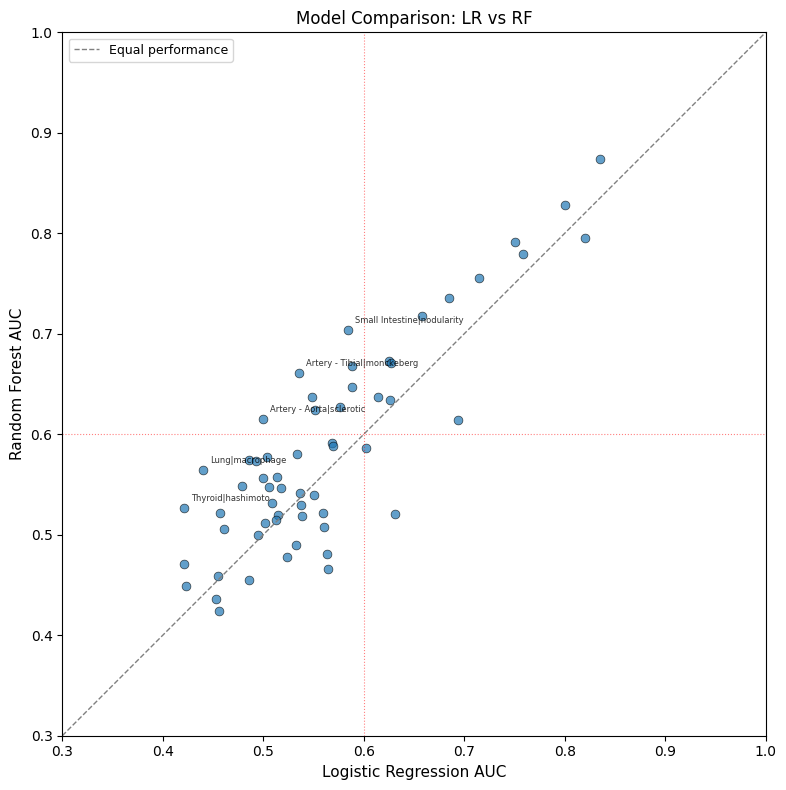

In [3]:
plot_comparison_scatter(comp,
                        save_path=Config.FIGURES_DIR / "comparison_scatter_lr_vs_rf.pdf")

## AUC Difference Bar Chart

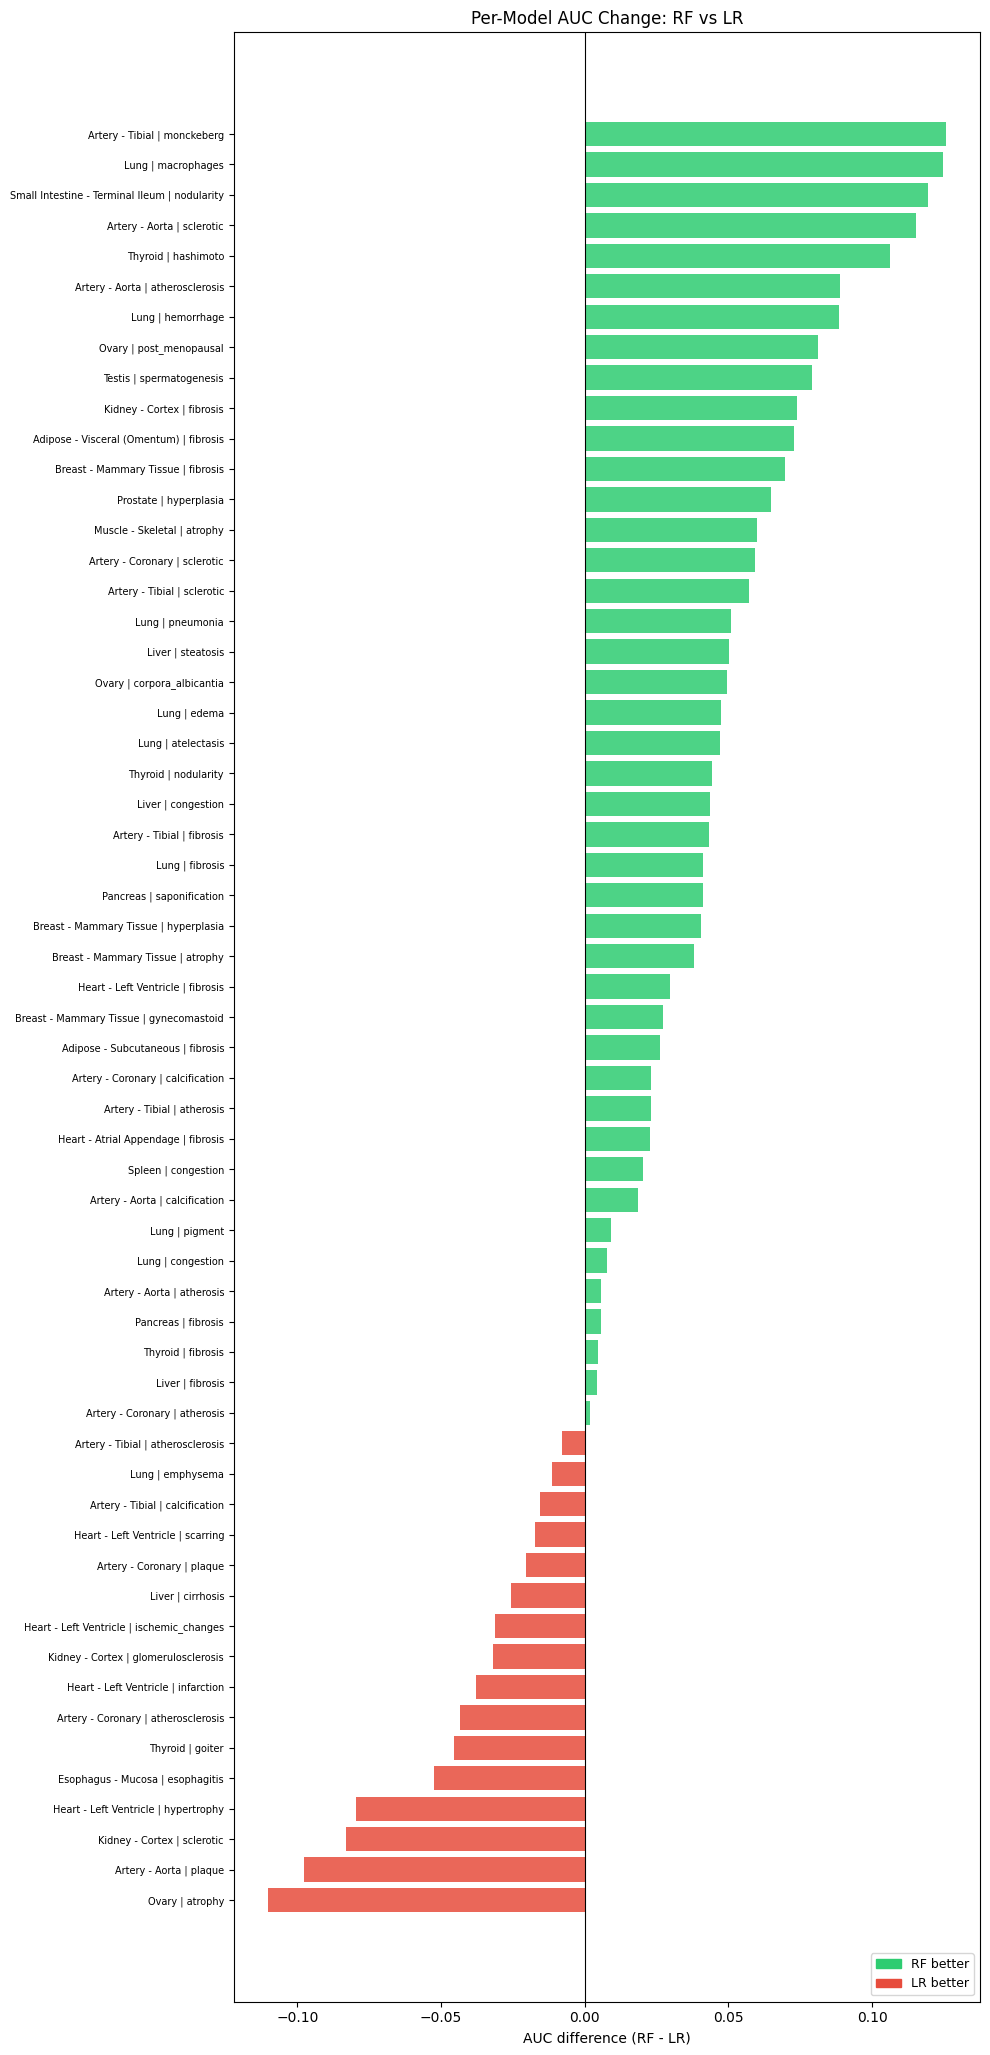

In [4]:
plot_comparison_barplot(comp,
                        save_path=Config.FIGURES_DIR / "comparison_barplot_auc_diff.pdf")